# Does a stock keep drifting after a **sales** surprise? 🧾
### The revenue-surprise drift — a famous academic cousin of post-earnings drift that, on big names, just **isn't there**

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Adds_info_beyond_EPS%3F: Busted](https://img.shields.io/badge/Adds_info_beyond_EPS%3F-Busted-8b949e?style=flat-square)

You've probably heard that when a company **beats** on earnings, its stock keeps drifting up for weeks (that's *post-earnings drift* — and it's [genuinely real](../../363-pead-drift)). In 2006 two accounting professors, **Jegadeesh & Livnat**, pushed the idea further: they said the drift also follows the **revenue** (sales) surprise — and, more strikingly, that the *sales* beat tells you something the *earnings* beat doesn't. The intuition is lovely: a beat powered by **growing sales** is more durable than one squeezed out of cost-cuts, so the market should under-react to surprising revenue specifically.

Lovely intuition. Does it survive on a basket of big, liquid, boring large-caps you could actually trade? **No.** When we sort 592 quarterly revenue surprises and look at what happens next, the drift is a **flat line that wanders around zero**.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo tests and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** We use a fixed **30-name large-cap basket** (names still trading today — that's **survivorship**) and pull quarterly revenue from **EDGAR** (the SEC's filing database). EDGAR's clean tagged revenue mostly starts ~2013, so this is a *thinner* sample than the earnings study. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from revenue_drift import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES, EV = data.load_real()      # event table carries the SUR
else:
    PRICES = EV = None
print("real revenue cache present:", HAVE_REAL,
      "| events:", (0 if EV is None else len(EV)),
      "| names:", (0 if EV is None else EV['ticker'].nunique()))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2013-02-11', 'end': '2026-06-03', 'years': 13.3, 'n_events': 592, 'n_names': 29, 'h1': (1, 592, 0.15, 0.02, 0.13, 51, 0.59, 0.281), 'h5': (5, 592, 0.47, 0.82, -0.35, 51, -0.7, 0.751), 'h20': (20, 586, 1.5, 1.04, 0.46, 50, 0.49, 0.32), 'h60': (60, 542, 2.81, 3.96, -1.15, 53, -0.75, 0.732), 'net': [(1, 0.13, -0.27), (5, -0.35, -0.76), (20, 0.46, 0.02), (60, -1.15, -1.67)], 'quintile20': [1.04, 2.8, 1.73, 0.5, 1.5], 'robust': [(3, -0.44, -0.59, 0.717), (5, 0.46, 0.49, 0.32), (10, -0.01, -0.02, 0.501)], 'block_p20': 0.582, 'inc': [('eps+ (beats)', 488, -0.3, -0.35), ('eps- (misses)', 72, -0.67, -0.19)], 'inc_pooled': (560, -0.19, -0.4), 'syn': [(0.0, 1224, 0.02, 0.03, 0.494, 48), (0.08, 1224, 5.38, 9.55, 0.0, 67)]}


real revenue cache present: True | events: 592 | names: 29


## The answer first

| Question | Answer |
|---|---|
| After a big **sales** beat, does the stock keep drifting up? | **No — not on these names.** The best-surprise minus worst-surprise spread is a measly **+0.13%** at 1 day and *negative* at 5 and 60 days. It's noise. |
| Is the cross-section at least tidy (more surprise → more drift)? | **No.** The *second* surprise bucket drifts the most; the top bucket is mid-pack. No ladder. |
| Does revenue tell you something earnings didn't (Jegadeesh-Livnat's big claim)? | **No.** Once we hold the *earnings* surprise's sign fixed, the revenue sort pays **−0.19%** (*t* = −0.40). The incremental signal vanishes. |
| Is our measuring stick just broken? | **No** — and this is the key check. On fake data with a drift *planted in on purpose*, the same code lights up at *t* = 9.55. The detector works fine; there's simply nothing to detect here. |

> The earnings version of this drift is real (see study 363). The **revenue** version, on a tradable large-cap basket, is a **mirage** — a great example of an academic result that doesn't carry over to where you'd actually trade.

## 1 · The claim

> *"When a company's **sales** come in far above expectations, the market is slow to fully appreciate it — so the stock keeps grinding higher for weeks. And the **sales** surprise is its own signal: it predicts future returns even after you account for the earnings surprise."*

This is **Jegadeesh & Livnat (2006)**, *Revenue surprises and stock returns*. It builds on the granddaddy anomaly — post-earnings-announcement drift — and adds a genuinely interesting twist: not all beats are equal, and the *sales-driven* ones should drift more because they're more durable. The question for us: **does it replicate** on big liquid names, 20 years later?

## 2 · So what?

If revenue surprises drifted, you'd have a clean, fundamental signal that's *harder to fake* than earnings (you can massage profits with accounting; sales are sales). And if it added information *beyond* earnings, you could stack it on top of the earnings drift for a better trade. Two big *ifs*.

But here's the catch that runs through this whole desk: a result that's strong in a 1980s–1990s full-universe academic sample (lots of small, illiquid, since-delisted firms) can **completely evaporate** on the liquid large-caps you can actually trade today — eaten by costs, arbitraged away after publication, or just never that strong on big names to begin with. We'll see exactly that.

## 3 · How would we even know?

We take a fixed **30-name large-cap basket** and pull every quarterly **revenue** figure from EDGAR — about **592 usable events** over **13 years** (2013-02-11 → 2026-06-03). For each one we compute:

1. **The surprise (SUR).** How much revenue beat or missed the simple expectation "same as this quarter *last year*" — then scaled by how bumpy that firm's revenue surprises usually are. (Big positive = a real sales blowout; this is the revenue twin of the academic *SUE* used for earnings.)
2. **The drift.** Starting the day **after** the filing is public (no cheating), how much does the stock move over the next **1, 5, 20, 60** trading days?
3. **The bet.** Sort events into five surprise buckets; go **long** the best, **short** the worst. If the claim is real, that long-short should make money — and we test it against a thousands-of-shuffles "could this be luck?" null.

## 4 · The teardown — let's actually look

**First, does the drift line up with the surprise?** Sort every event into five buckets by how big the revenue surprise was, and plot the average 20-day drift of each bucket. If the claim holds, it should climb from left (worst misses) to right (best beats).

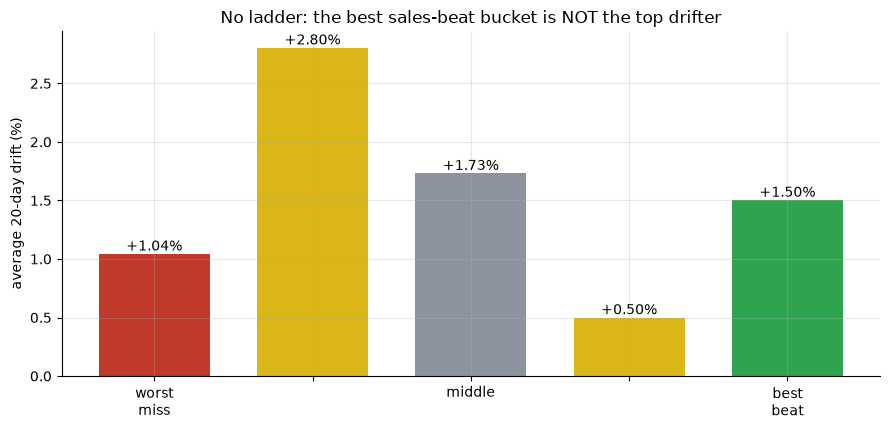

best-beat bucket: +1.50%   worst-miss bucket: +1.04%   spread: +0.46%


In [2]:
if HAVE_REAL:
    fr = st.event_drift_frame(PRICES, EV, 20)
    q = st.bucket_means(fr, 'sur') * 100
else:
    q = np.array(R['quintile20'])
fig, ax = plt.subplots(figsize=(9.0, 4.4))
labels = ['worst\nmiss','','middle','','best\nbeat']
cols = [RED, AMBER, GREY, AMBER, GREEN]
ax.bar(range(5), q, color=cols, width=.7)
for i,v in enumerate(q): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom')
ax.set_xticks(range(5)); ax.set_xticklabels(labels)
ax.set_ylabel('average 20-day drift (%)')
ax.set_title('No ladder: the best sales-beat bucket is NOT the top drifter')
plt.tight_layout(); plt.show()
print(f'best-beat bucket: {q[-1]:+.2f}%   worst-miss bucket: {q[0]:+.2f}%   '
      f'spread: {q[-1]-q[0]:+.2f}%')

No ladder. The best-beat bucket drifts **+1.50%** over 20 days — but so does the *worst*-miss bucket (**+1.04%**), and the **second** bucket (**+2.80%**) is the highest of all. If the revenue surprise drove the drift, the bars would climb left-to-right. They don't.

**And the long-short over time?** Here's the spread (best beats minus worst misses) at four horizons. A real drift would be positive and growing. Watch it wander.

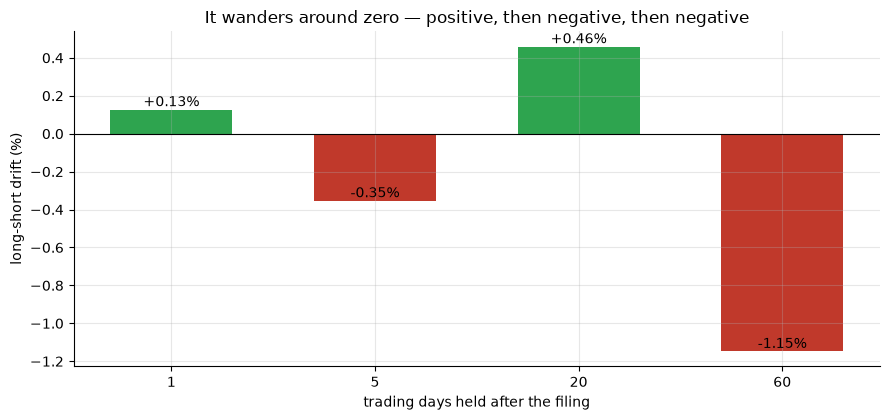

1-day: +0.13%  5-day: -0.35%  20-day: +0.46%  60-day: -1.15%


In [3]:
hs = [1, 5, 20, 60]
if HAVE_REAL:
    ls = [st.summarize(PRICES, EV, h, surprise_col='sur', placebo=False)['ls_mean']*100 for h in hs]
else:
    ls = [R['h1'][4], R['h5'][4], R['h20'][4], R['h60'][4]]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
cols = [GREEN if v>0 else RED for v in ls]
ax.bar([str(h) for h in hs], ls, color=cols, width=.6)
for i,v in enumerate(ls): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_xlabel('trading days held after the filing'); ax.set_ylabel('long-short drift (%)')
ax.set_title('It wanders around zero — positive, then negative, then negative')
plt.tight_layout(); plt.show()
print('1-day:', f'{ls[0]:+.2f}%', ' 5-day:', f'{ls[1]:+.2f}%', ' 20-day:', f'{ls[2]:+.2f}%', ' 60-day:', f'{ls[3]:+.2f}%')

There's no drift to ride. **+0.13%** at 1 day, **-0.35%** at 5 days (negative!), **+0.46%** at 20, **-1.15%** at 60 (negative again). The sign flips around — the signature of noise, not a signal.

**The crucial sanity check.** Maybe our measuring stick is broken? Let's feed the *exact same code* fake data where we **planted** a real drift on purpose. If the code is honest, it should (a) find **nothing** when there's nothing, and (b) **light up** when there's something.

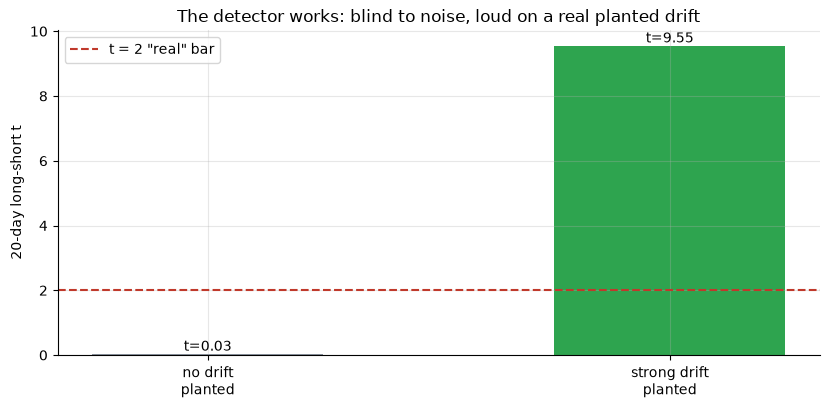

planted nothing -> t = 0.03 | planted strong drift -> t = 9.55


In [4]:
res = []
for edge in (0.0, 0.08):
    px, e = data.synthetic_rev(edge=edge, seed=534)
    s = st.summarize(px, e, 20, n_draws=2000)
    res.append((edge, s['t']))
fig, ax = plt.subplots(figsize=(8.4, 4.2))
ax.bar(['no drift\nplanted','strong drift\nplanted'], [r[1] for r in res], color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t = 2 "real" bar')
for i,r in enumerate(res): ax.annotate(f't={r[1]:.2f}',(i,r[1]),ha='center',va='bottom')
ax.set_ylabel('20-day long-short t'); ax.legend()
ax.set_title('The detector works: blind to noise, loud on a real planted drift')
plt.tight_layout(); plt.show()
print('planted nothing -> t =', round(res[0][1],2), '| planted strong drift -> t =', round(res[1][1],2))

Exactly right. With **no** planted drift the code sits at **t = 0.03** (it doesn't invent a signal); with a **strong** planted drift it screams at **t = 9.55**. So the flat real-tape result isn't a bug — **there's genuinely no revenue drift to find on these names.**

## 5 · The verdict

- **Signal — None.** The revenue-surprise drift **never clears the bar** — no horizon, no bucket count, and a placebo says it's indistinguishable from a random sort. The detector works (it nails a planted drift); there's just no signal here.
- **Tradability — Mirage.** Nothing gross to begin with, and costs push it negative. There's no trade.
- **"Adds info beyond earnings"? — Busted.** Once you hold the *earnings* surprise fixed, the revenue sort adds **nothing** (it's slightly negative). Jegadeesh-Livnat's headline claim doesn't replicate on this basket.

## 6 · The honest contrast — earnings drift *is* real, revenue drift isn't

The point isn't "drift is fake." The *earnings* version ([study 363](../../363-pead-drift)) clears the bar on a near-identical basket. It's specifically the **revenue** twin — and especially its *incremental* claim — that doesn't survive here. Same machinery, same kind of names, opposite verdict.

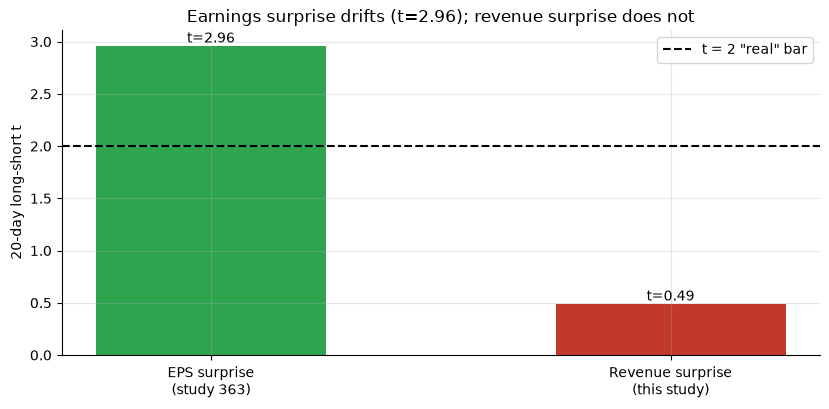

EPS drift t (363): 2.96 | revenue drift t (here): 0.49


In [5]:
labels = ['EPS surprise\n(study 363)', 'Revenue surprise\n(this study)']
tvals = [2.96, R['h20'][6]]   # 363's 20-day t vs ours
fig, ax = plt.subplots(figsize=(8.4, 4.2))
ax.bar(labels, tvals, color=[GREEN, RED], width=.5)
ax.axhline(2, ls='--', c='k', label='t = 2 "real" bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20-day long-short t'); ax.legend()
ax.set_title('Earnings surprise drifts (t=2.96); revenue surprise does not')
plt.tight_layout(); plt.show()
print('EPS drift t (363):', 2.96, '| revenue drift t (here):', round(R['h20'][6],2))

> The earnings surprise clears **t = 2.96**; the revenue surprise sits at **t = 0.49**. The *fundamental* that drifts is earnings, not sales — at least on a tradable large-cap basket in the 2013–2026 window.

## 7 · Going further 🚪

- **Why might it be gone?** The whole drift family is **strongest in small, illiquid stocks** (Chordia et al. 2009) — which we *excluded* by using liquid large-caps. And published anomalies **decay** (McLean & Pontiff 2016): Jegadeesh-Livnat is 20 years old.
- **The lesson.** A beautiful, intuitive academic result is *not* a tradable edge until you replicate it on the names and the era you'd actually trade — with costs and an honest null.
- **Build your own.** Swap the basket for small-caps, or pre-2013 data, and the revenue drift may re-appear (with bigger costs and worse survivorship). The **incremental-to-earnings** test is the hard part — that's the claim that really fails here.

*Think the revenue drift is hiding somewhere? Show the SUR long-short clearing **t = 2** after honest costs and a placebo — then we'll talk.*